In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [23]:
df_spotify = pd.read_csv(r'C:\Users\santa\Desktop\ETL_cositas\workshop_02\data\raw\spotify_dataset.csv')

In [24]:
df_spotify.head(7)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic


In [25]:
print("Shape or df dimensions:", df_spotify.shape)
print("\nColumns:")
print(df_spotify.columns.tolist())

Shape or df dimensions: (114000, 21)

Columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [26]:
# Data types
print("Data types:", df_spotify.dtypes)

Data types: Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


In [5]:
# Missing values
print("Missing values:")
print(df_spotify.isnull().sum())
print((df_spotify.isnull().sum() / len(df_spotify) * 100).round(2))

Missing values:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
Unnamed: 0          0.0
track_id            0.0
artists             0.0
album_name          0.0
track_name          0.0
popularity          0.0
duration_ms         0.0
explicit            0.0
danceability        0.0
energy              0.0
key                 0.0
loudness            0.0
mode                0.0
speechiness         0.0
acousticness        0.0
instrumentalness    0.0
liveness            0.0
valence             0.0
tempo               0.0
time_signature      0.0
track_genre         0.0
dtype

In [9]:
# Cardinality od categorical columns
# Check cardinality of categorical columns
print("\nCardinality of categorical columns:")
    
categorical_cols = ["popularity", "track_genre", "artist_genre", "artist_name", "track_name"]

for col in categorical_cols:
    if col in df_spotify.columns:
        print(f"\n{col}:")
        print("Unique values:", df_spotify[col].nunique())
        print("Top values:")
        print(df_spotify[col].value_counts().head())


Cardinality of categorical columns:

popularity:
Unique values: 101
Top values:
popularity
0     16020
22     2354
21     2344
44     2288
1      2140
Name: count, dtype: int64

track_genre:
Unique values: 114
Top values:
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
Name: count, dtype: int64

track_name:
Unique values: 73608
Top values:
track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 81
Little Saint Nick - 1991 Remix     76
Last Last                          75
Name: count, dtype: int64


In [10]:
# Basic Statistics
print("Describe data:")
df_spotify.describe()

Describe data:


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [17]:
audio_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]
df_spotify[audio_cols].describe().round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,0.567,0.641,-8.259,0.085,0.315,0.156,0.214,0.474,122.148
std,0.174,0.252,5.029,0.106,0.333,0.310,0.190,0.259,29.978
min,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.456,0.472,-10.013,0.036,0.017,0.000,0.098,0.260,99.219
50%,0.580,0.685,-7.004,0.049,0.169,0.000,0.132,0.464,122.017
75%,0.695,0.854,-5.003,0.084,0.598,0.049,0.273,0.683,140.071
max,0.985,1.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372


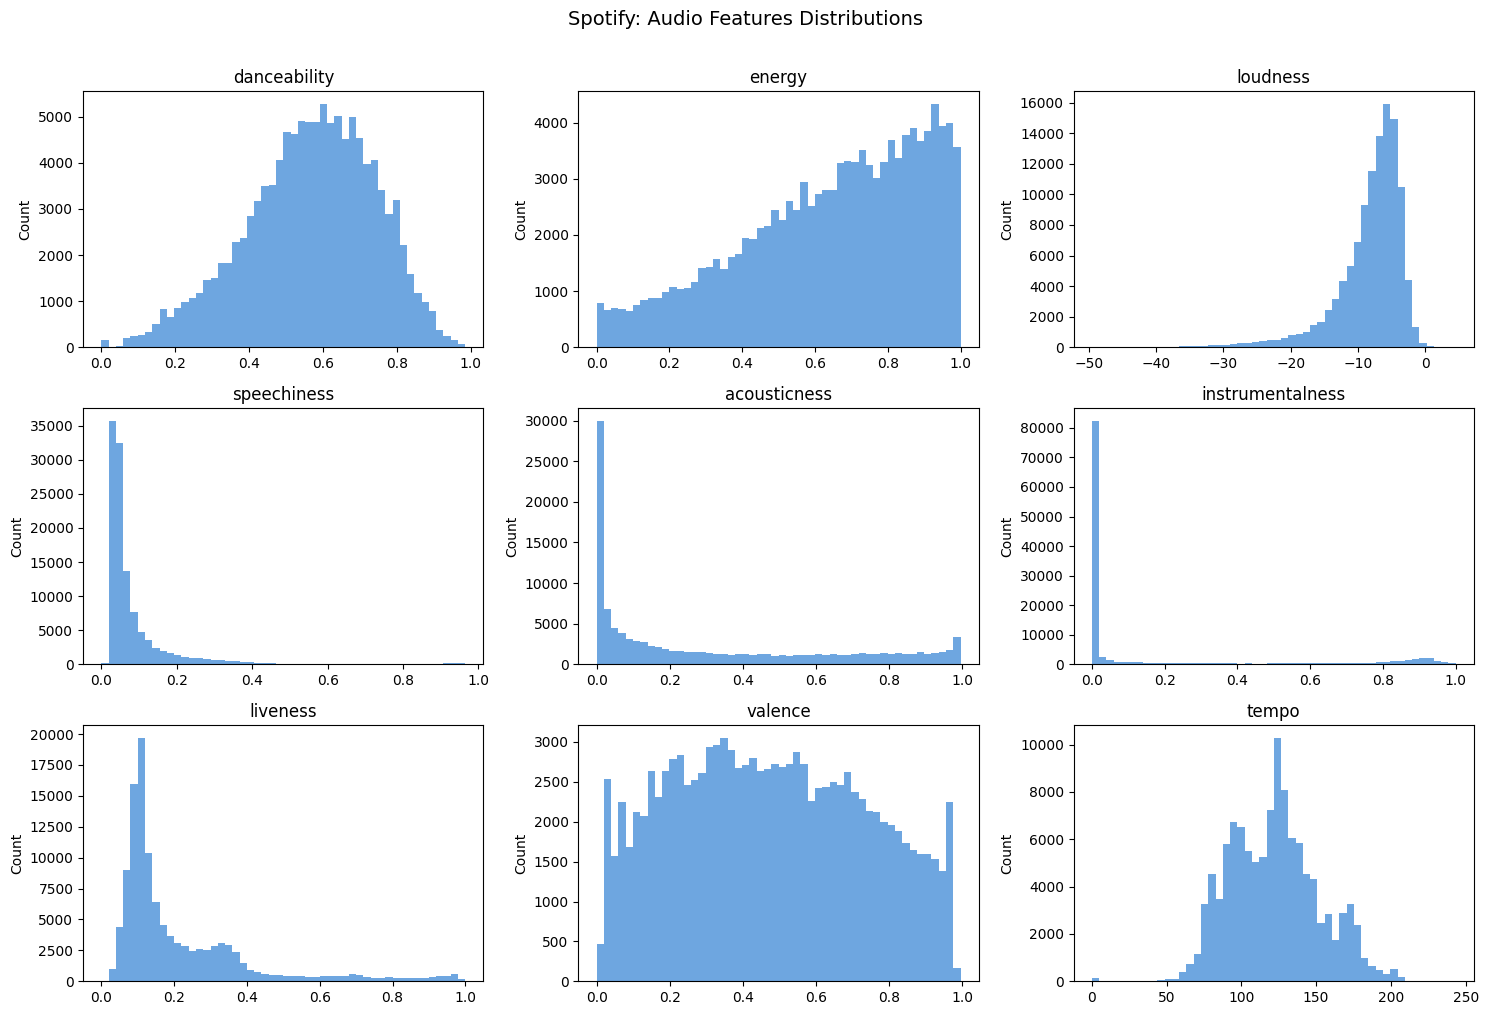

In [18]:
#Audio features. Distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
 
for i, col in enumerate(audio_cols):
    axes[i].hist(df_spotify[col], bins=50, color="#4A90D9", alpha=0.8, edgecolor="none")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
 
plt.suptitle("Spotify: Audio Features Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [12]:
print("Fully duplicated rows:", df_spotify.duplicated().sum())
print("Duplicate track_id:   ", df_spotify["track_id"].duplicated().sum())

Fully duplicated rows: 0
Duplicate track_id:    24259


In [ ]:

# Sample of same songs with multiple genres
df_spotify[df_spotify["track_id"].duplicated(keep=False)]\
    .sort_values("track_id")[["track_id", "track_name", "artists", "track_genre"]]\
    .head(15)

,track_id,track_name,artists,track_genre
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,chill
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,soul
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,rock
3257,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alternative
2106,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,emo
94239,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,sad
97533,006rHBBNLJMpQs8fRC2GDe,Agora Estou Sofrendo - Ao Vivo,Calcinha Preta;Gusttavo Lima,sertanejo


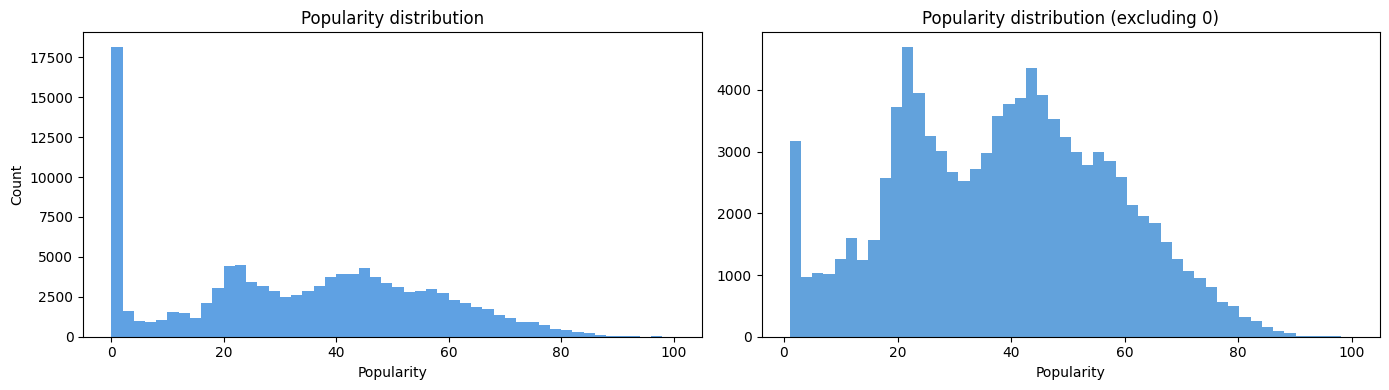

Rows with popularity = 0: 16020 (14.1%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
axes[0].hist(df_spotify["popularity"], bins=50, color="#378ADD", alpha=0.8)
axes[0].set_title("Popularity distribution")
axes[0].set_xlabel("Popularity")
axes[0].set_ylabel("Count")
 
df_spotify_no_zero = df_spotify[df_spotify["popularity"] > 0]
axes[1].hist(df_spotify_no_zero["popularity"], bins=50, color="#3B8BD4", alpha=0.8)
axes[1].set_title("Popularity distribution (excluding 0)")
axes[1].set_xlabel("Popularity")
 
plt.tight_layout()
plt.show()
 
print(f"Rows with popularity = 0: {(df_spotify['popularity'] == 0).sum()} ({(df_spotify['popularity'] == 0).mean()*100:.1f}%)")

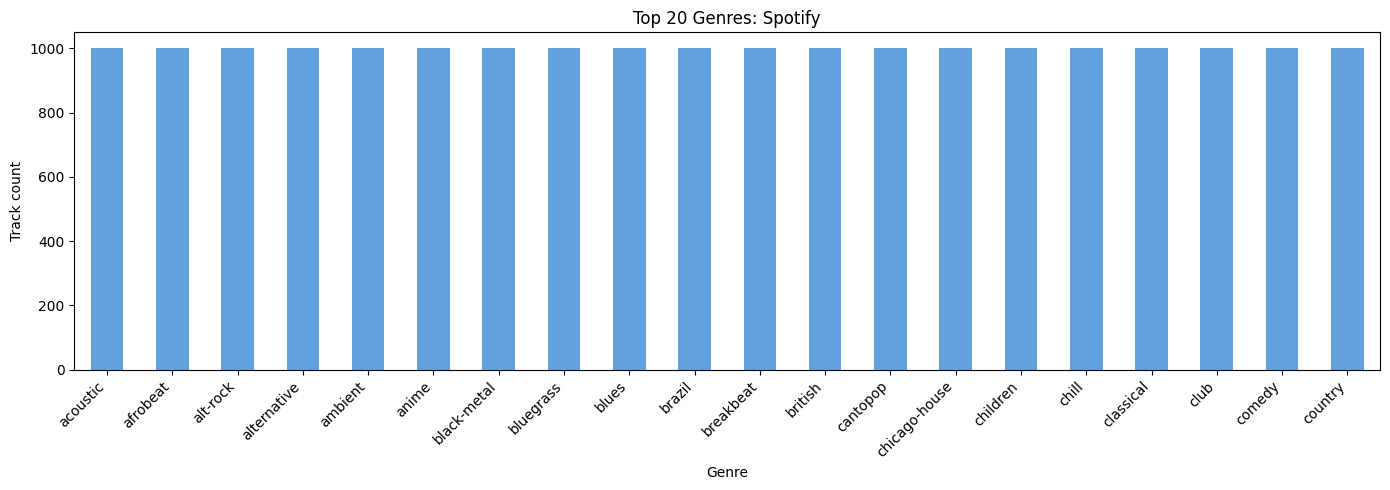

Total unique genres: 114


In [21]:
# Genre distribution
top_genres = df_spotify["track_genre"].value_counts().head(20)
 
plt.figure(figsize=(14, 5))
top_genres.plot(kind="bar", color="#4A90D9", alpha=0.85)
plt.title("Top 20 Genres: Spotify")
plt.xlabel("Genre")
plt.ylabel("Track count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
 
print(f"Total unique genres: {df_spotify['track_genre'].nunique()}")

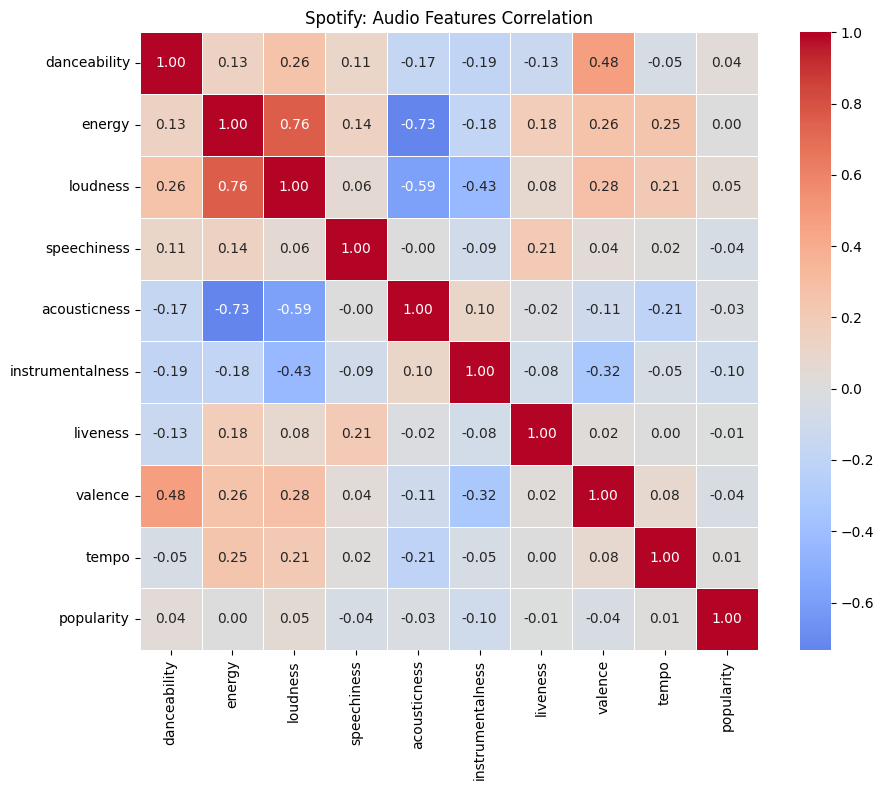

In [28]:
# Correlation heatmap — audio features
corr = df_spotify[audio_cols + ["popularity"]].corr()
 
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Spotify: Audio Features Correlation")
plt.tight_layout()
plt.show()

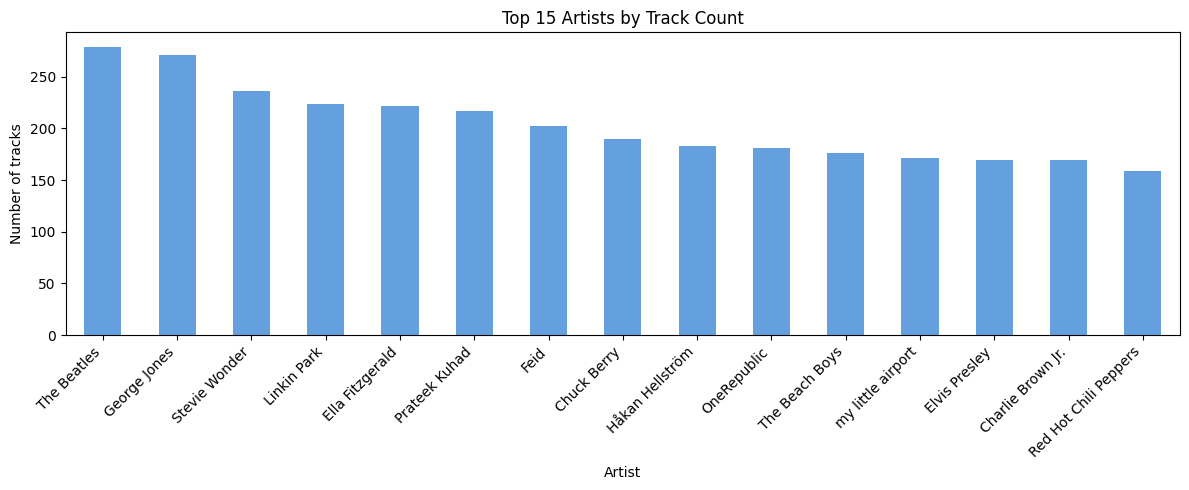

In [29]:
# Top artists by track count
top_artists = df_spotify["artists"].value_counts().head(15)
 
plt.figure(figsize=(12, 5))
top_artists.plot(kind="bar", color="#4A90D9", alpha=0.85)
plt.title("Top 15 Artists by Track Count")
plt.xlabel("Artist")
plt.ylabel("Number of tracks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [30]:
# %% Explicit tracks
explicit_pct = df_spotify["explicit"].value_counts(normalize=True) * 100
print("Explicit tracks (%):")
print(explicit_pct.round(2))

Explicit tracks (%):
explicit
False    91.45
True      8.55
Name: proportion, dtype: float64
